# **ANALYSIS WIHTOUT GAP_NOSOC FEATURE**

Reproducing results from ['Bandgap prediction of 2D materials using machine learning', https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0255637 ]

In [139]:
pip install scikit-learn pandas numpy matplotlib seaborn ase

In [140]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot  as plt
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn import ensemble
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# **DATA PREPROCESSING**

In [141]:
df = pd.read_csv('/content/bostonvolume.csv')

In [142]:
df.head()

,dosef,energy,natom,mass,fmax,smax,hform,volume,gap
0,0.000000,-34.420158,8,847.104000,0.000441,0.000025,-0.242520,554.583570,0.198787
1,0.598768,-51.326923,7,228.473000,0.006010,0.000092,-1.486560,210.204206,0.000000
2,4.600808,-16.355219,6,439.664400,0.003162,0.000085,0.108463,399.866678,0.000000
3,0.000000,-8.558619,3,461.008940,0.008155,0.000085,-0.614540,334.657508,1.577069
4,3.637586,-28.363150,4,149.864388,0.002523,0.000387,-0.414287,252.368393,0.000000


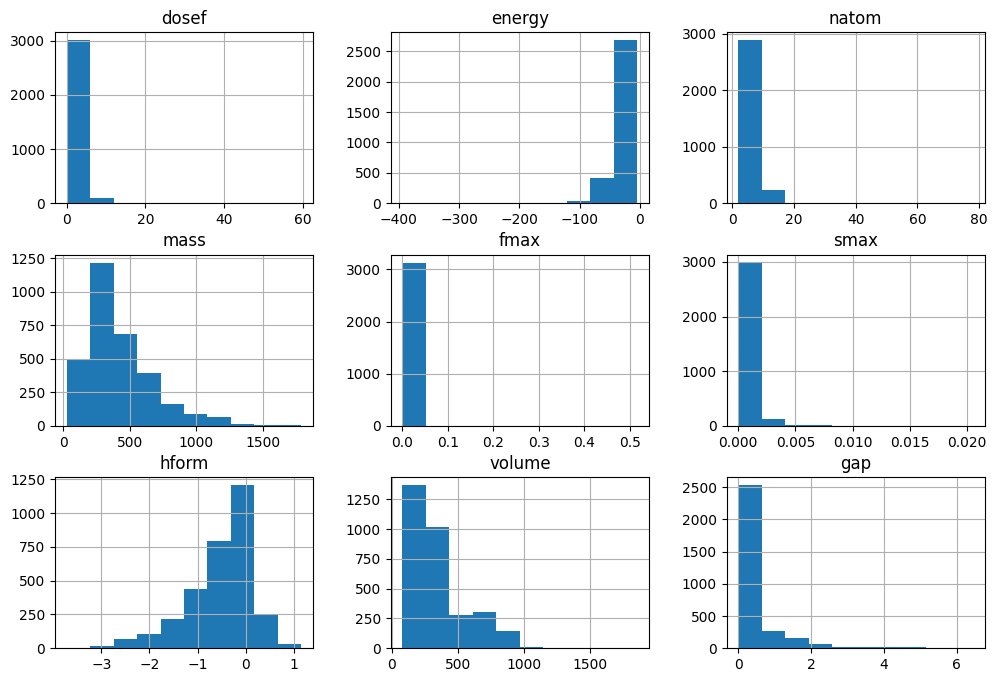

In [143]:
df.hist(figsize=(12, 8))
plt.show()


In [144]:
df.skew()

,0
dosef,8.838318
energy,-6.081964
natom,10.597072
mass,1.456473
fmax,29.644474
smax,7.815979
hform,-1.076341
volume,1.500754
gap,3.273621


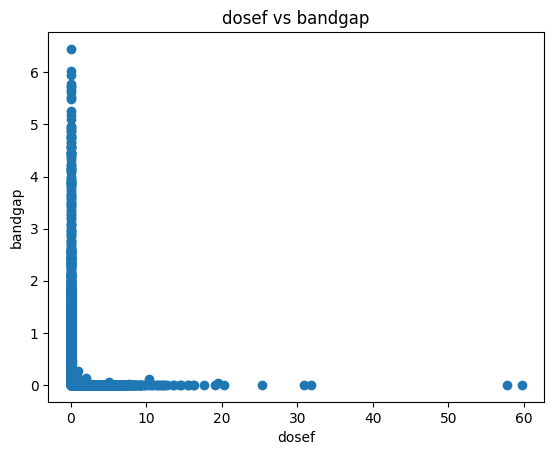

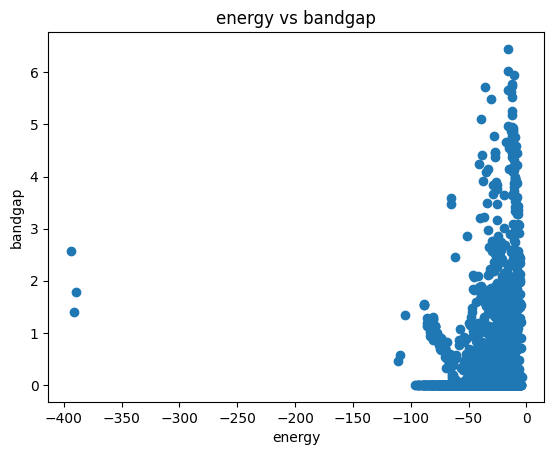

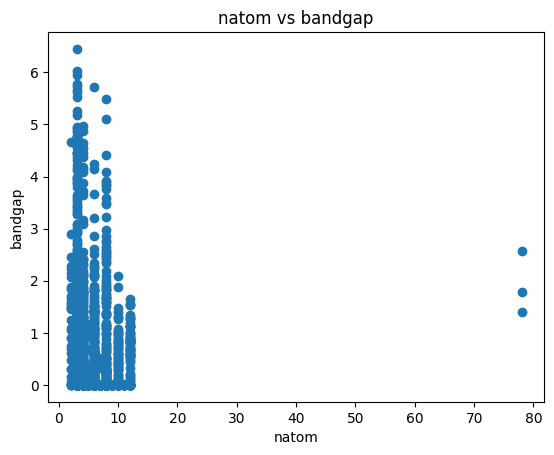

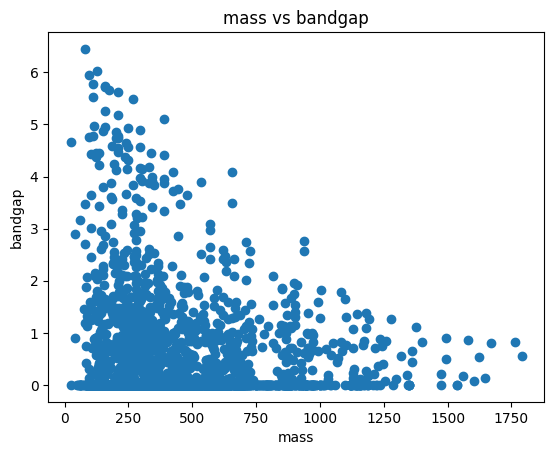

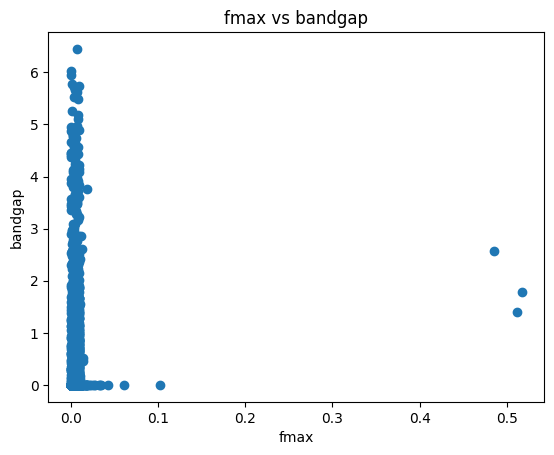

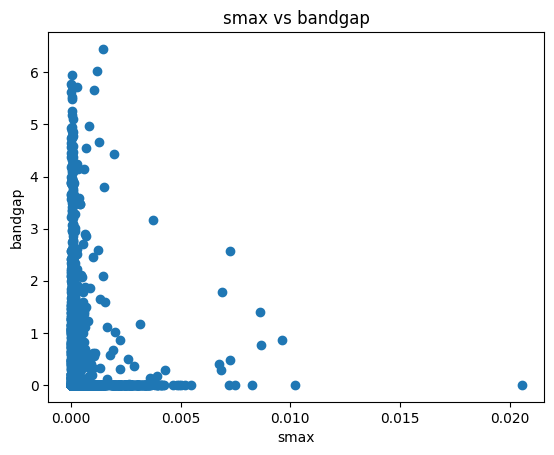

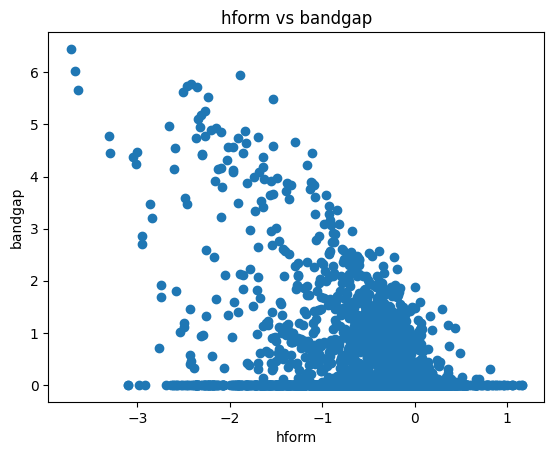

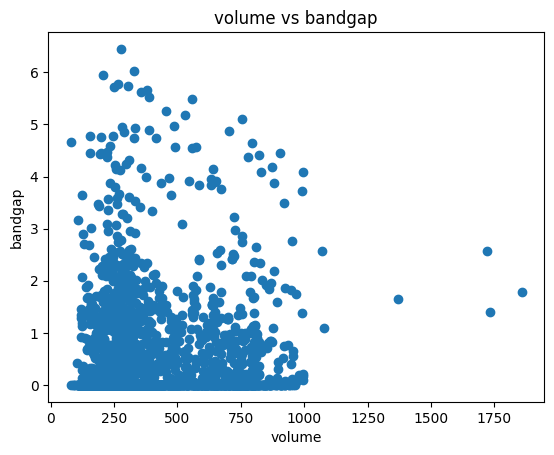

In [145]:
for i in range(8):
  plt.scatter(df.iloc[:,i], df.iloc[:,8])
  plt.xlabel(df.columns[i])
  plt.ylabel('bandgap')
  plt.title(f'{df.columns[i]} vs bandgap')
  plt.show()


In [146]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 0:8], df.iloc[:, 8], test_size = 0.1, random_state = 0)

In [147]:
'''from sklearn.preprocessing import PowerTransformer
pwr = PowerTransformer()
X_train = pwr.fit_transform(X_train)
X_test = pwr.transform(X_test)'''

'from sklearn.preprocessing import PowerTransformer\npwr = PowerTransformer()\nX_train = pwr.fit_transform(X_train)\nX_test = pwr.transform(X_test)'

In [148]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

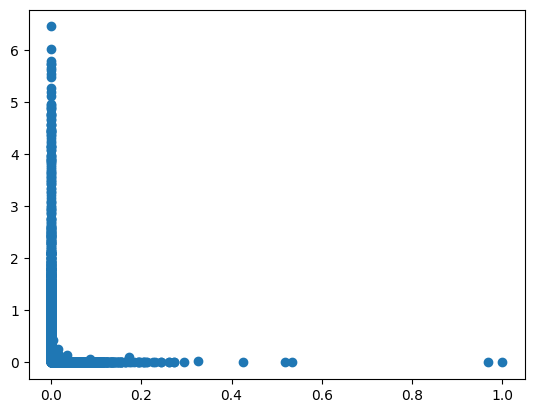

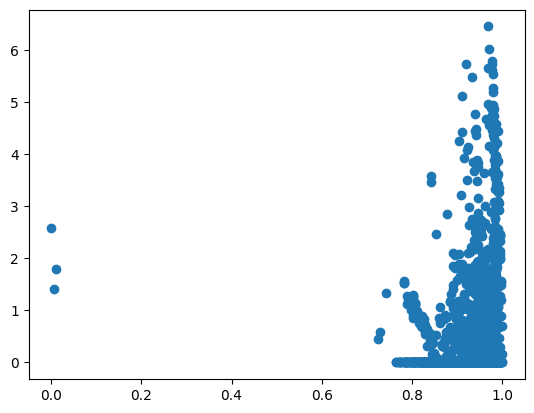

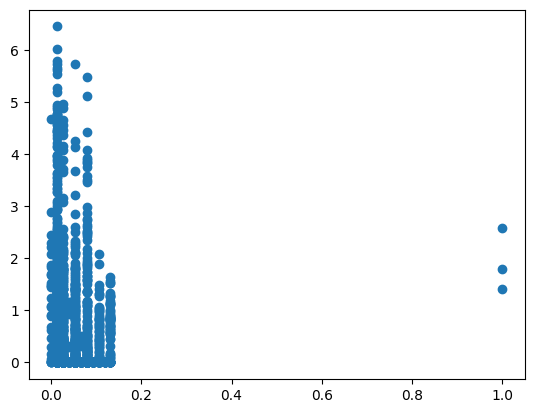

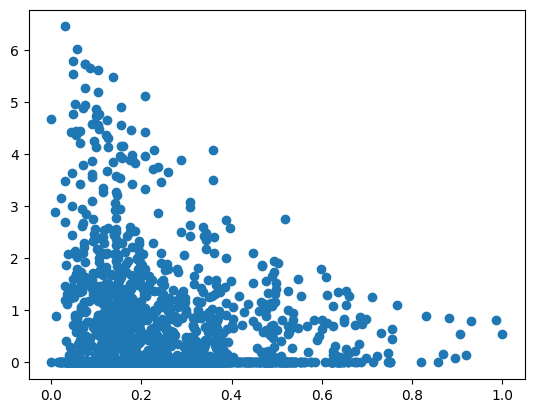

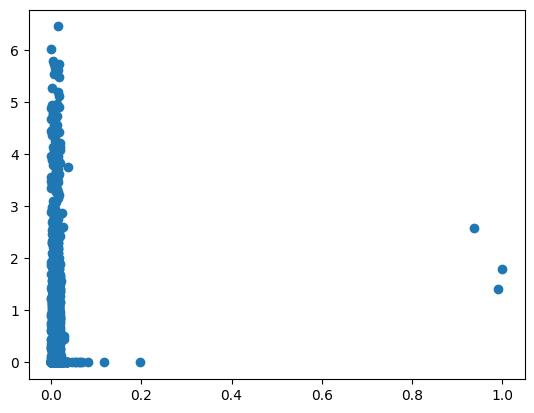

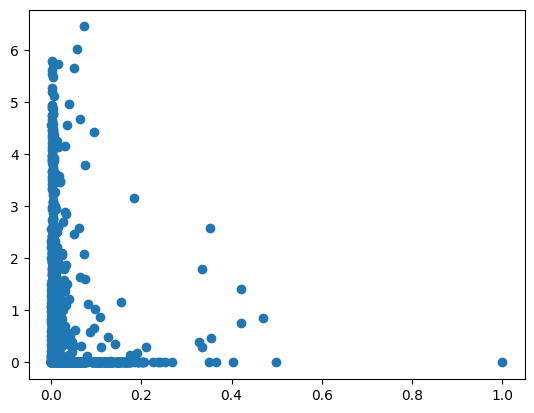

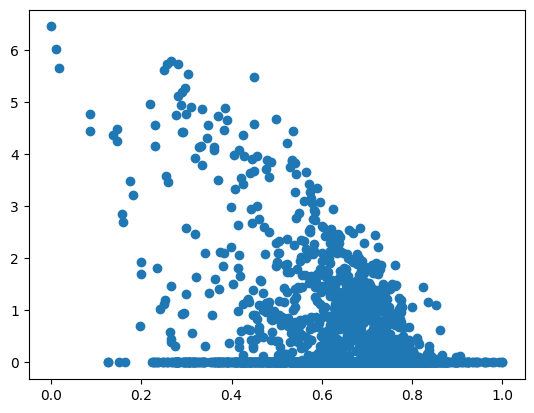

In [149]:
for i in range(7):
  plt.scatter(X_train[:,i], y_train)
  plt.show()


# **SVR**

In [150]:
kernel = 'rbf'
C = [50]
gamma = [50]
epsilon = [0.2]

In [151]:
params_dict = {
	'C': C,
	'gamma': gamma,
	'epsilon': epsilon
}

In [152]:
svr = SVR()
gscv = GridSearchCV(
    estimator = svr,
    param_grid = params_dict,
    n_jobs = 2,
    scoring = 'r2',
    cv = 6
)
gscv.fit(X_train, y_train)

GridSearchCV(cv=6, estimator=SVR(), n_jobs=2,
             param_grid={'C': [50], 'epsilon': [0.2], 'gamma': [50]},
             scoring='r2')

In [153]:
svr = SVR(C=gscv.best_params_['C'], kernel=kernel, gamma=gscv.best_params_['gamma'],
      	epsilon=gscv.best_params_['epsilon'])
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)

In [154]:
print("Model evaluation - SVR:")
print('r^2:',r2_score(y_test, svr_pred))
print('RSE', mean_squared_error(y_test, svr_pred))
print('RAE', mean_absolute_error(y_test, svr_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,svr_pred)))

Model evaluation - SVR:
r^2: 0.7379921025275554
RSE 0.17357325075576369
RAE 0.24362127145229498
RMSE: 0.4166212317630532


# **RANDOM FOREST**

In [137]:
rf=RandomForestRegressor(criterion='absolute_error',bootstrap=False,max_features=0.8,
max_depth=20,min_samples_split=5, n_estimators=100,min_samples_leaf=3,random_state=0, n_jobs = -1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [138]:
print("Model evaluation - Random Forest:")
print('r^2:',r2_score(y_test, rf_pred))
print('RSE', mean_squared_error(y_test, rf_pred))
print('RAE', mean_absolute_error(y_test, rf_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,rf_pred)))

Model evaluation - Random Forest:
r^2: 0.9063348836396111
RSE 0.06205064383908273
RAE 0.09691773384426516
RMSE: 0.24909966647726112


# **GRADIENT BOOSTING**

In [155]:
params = {'n_estimators':200, 'max_depth': 21, 'min_samples_split': 5,
          'max_features':0.8,'learning_rate': 0.02, 'loss': 'squared_error',
          'random_state':0,'subsample': 0.85}
gbr = ensemble.GradientBoostingRegressor(**params)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

In [156]:
print("Model evaluation - Gradient Boosting:")
print('r^2:',r2_score(y_test, gbr_pred))
print('RSE', mean_squared_error(y_test, gbr_pred))
print('RAE', mean_absolute_error(y_test, gbr_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,gbr_pred)))

Model evaluation - Gradient Boosting:
r^2: 0.9095869690963037
RSE 0.059896223877321714
RAE 0.10110526170964551
RMSE: 0.24473705047932917


# **MULTI LAYER PERCEPTRON**

In [157]:
from sklearn.neural_network import MLPRegressor

In [158]:
mlp_hw = MLPRegressor(solver='adam',hidden_layer_sizes=(262,140,139,180),activation='tanh',alpha=1e-8,
                 	tol=1e-6,max_iter=5000,learning_rate='constant',
                 	learning_rate_init=0.001,random_state=120)
mlp_hw.fit(X_train, y_train)

MLPRegressor(activation='tanh', alpha=1e-08,
             hidden_layer_sizes=(262, 140, 139, 180), max_iter=5000,
             random_state=120, tol=1e-06)

In [159]:
mlp_pred = mlp_hw.predict(X_test)

In [160]:
print("Model evaluation - Multi layer perceptron:")
print('r^2:',r2_score(y_test, mlp_pred))
print('RSE', mean_squared_error(y_test, mlp_pred))
print('RAE', mean_absolute_error(y_test, mlp_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,mlp_pred)))

Model evaluation - Multi layer perceptron:
r^2: 0.8229025953122489
RSE 0.1173223117646477
RAE 0.18251002326679258
RMSE: 0.34252344702902854


# **MODEL ANALYSIS**

In [161]:
analysis_result = {
    'Model' : ['SVR', 'RF', 'GBDT', 'MLP'],
    'R^2' : [r2_score(y_test, svr_pred), r2_score(y_test, rf_pred),
             r2_score(y_test, gbr_pred), r2_score(y_test, mlp_pred)],
    'RSE' : [mean_squared_error(y_test, svr_pred), mean_squared_error(y_test, rf_pred),
             mean_squared_error(y_test, gbr_pred), mean_squared_error(y_test, mlp_pred)],
    'RAE' : [mean_absolute_error(y_test, svr_pred), mean_absolute_error(y_test, rf_pred),
             mean_absolute_error(y_test, gbr_pred), mean_absolute_error(y_test, mlp_pred)],
    'RMSE' : [np.sqrt(mean_squared_error(y_test,svr_pred)),
              np.sqrt(mean_squared_error(y_test,rf_pred)),
              np.sqrt(mean_squared_error(y_test,gbr_pred)),
              np.sqrt(mean_squared_error(y_test,mlp_pred))]

}

results = pd.DataFrame(analysis_result)
results

,Model,R^2,RSE,RAE,RMSE
0,SVR,0.737992,0.173573,0.243621,0.416621
1,RF,0.906335,0.062051,0.096918,0.249100
2,GBDT,0.909587,0.059896,0.101105,0.244737
3,MLP,0.822903,0.117322,0.182510,0.342523


In [162]:
def error_percentages(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    abs_err = np.abs(y_true - y_pred)
    mask = y_true > 0.05
    abs_err = abs_err[mask]
    total = len(abs_err)
    lt10 = np.sum(abs_err < 0.1)  / total * 100
    lt20 = np.sum((abs_err >= 0.1) & (abs_err < 0.2)) / total * 100
    gt20 = np.sum(abs_err >= 0.2) / total * 100
    return [lt10, lt20, gt20]
models = {
    'GBDT': error_percentages(y_test, gbr_pred),
    'RF':   error_percentages(y_test, rf_pred),
    'SVR':  error_percentages(y_test, svr_pred),
    'MLP':  error_percentages(y_test, mlp_pred),
}

In [163]:
models

{'GBDT': [np.float64(22.47191011235955),
  np.float64(23.595505617977526),
  np.float64(53.93258426966292)],
 'RF': [np.float64(21.34831460674157),
  np.float64(19.101123595505616),
  np.float64(59.55056179775281)],
 'SVR': [np.float64(17.97752808988764),
  np.float64(23.595505617977526),
  np.float64(58.42696629213483)],
 'MLP': [np.float64(14.606741573033707),
  np.float64(23.595505617977526),
  np.float64(61.79775280898876)]}

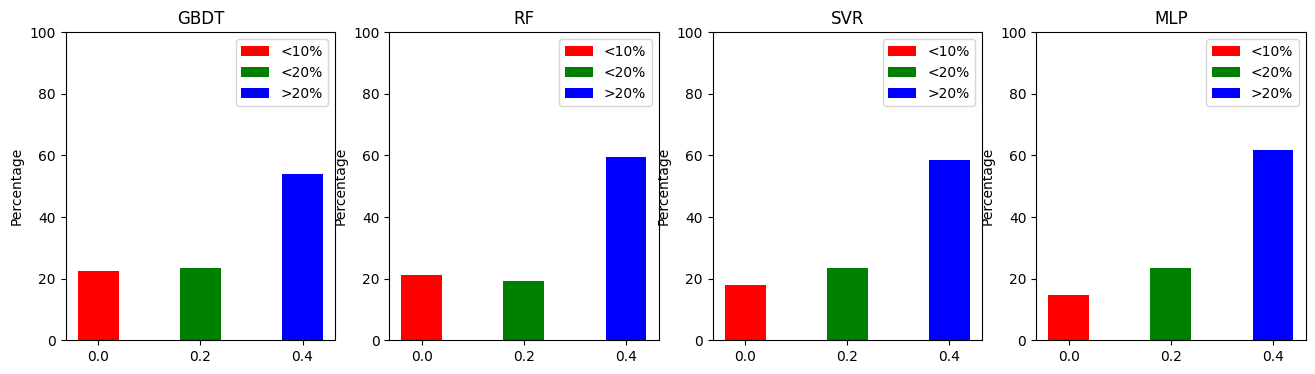

In [164]:
colors = ['red', 'green', 'blue']
labels = ['<10%', '<20%', '>20%']
x = [0.0, 0.2, 0.4]
bar_width = 0.08
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
model_names = list(models.keys())
model_values = list(models.values())
for i in range(4):
    ax = axes[i]
    model_name = model_names[i]
    percentages = model_values[i]
    ax.bar(x[0], percentages[0], width=bar_width, color=colors[0])
    ax.bar(x[1], percentages[1], width=bar_width, color=colors[1])
    ax.bar(x[2], percentages[2], width=bar_width, color=colors[2])
    ax.set_title(model_name)
    ax.set_ylabel('Percentage')
    ax.set_xticks(x)
    ax.set_xticklabels(['0.0', '0.2', '0.4'])
    ax.set_ylim(0, 100)
    ax.legend(labels)

plt.show()

In [165]:
svr_train_pred = svr.predict(X_train)
rf_train_pred = rf.predict(X_train)
gbr_train_pred = gbr.predict(X_train)
mlp_train_pred = mlp_hw.predict(X_train)

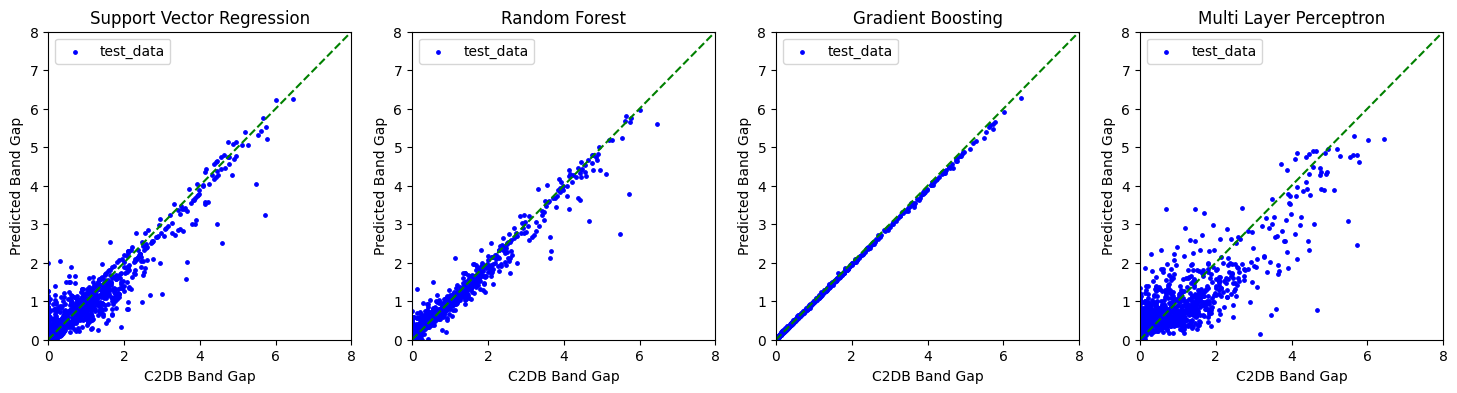

In [166]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
model_names = ['Support Vector Regression', 'Random Forest', 'Gradient Boosting', 'Multi Layer Perceptron']
predictions = [svr_train_pred, rf_train_pred, gbr_train_pred, mlp_train_pred]
for i in range(4):
    ax = axes[i]
    name = model_names[i]
    prediction = predictions[i]
    ax.scatter(y_train, prediction,s = 6, color = 'blue')
    ax.plot([0, 8], [0, 8], linestyle='--',color = 'green')
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 8)

    ax.set_xlabel('C2DB Band Gap')
    ax.set_ylabel('Predicted Band Gap')
    ax.set_title(name)
    ax.legend(['test_data'])

plt.show()

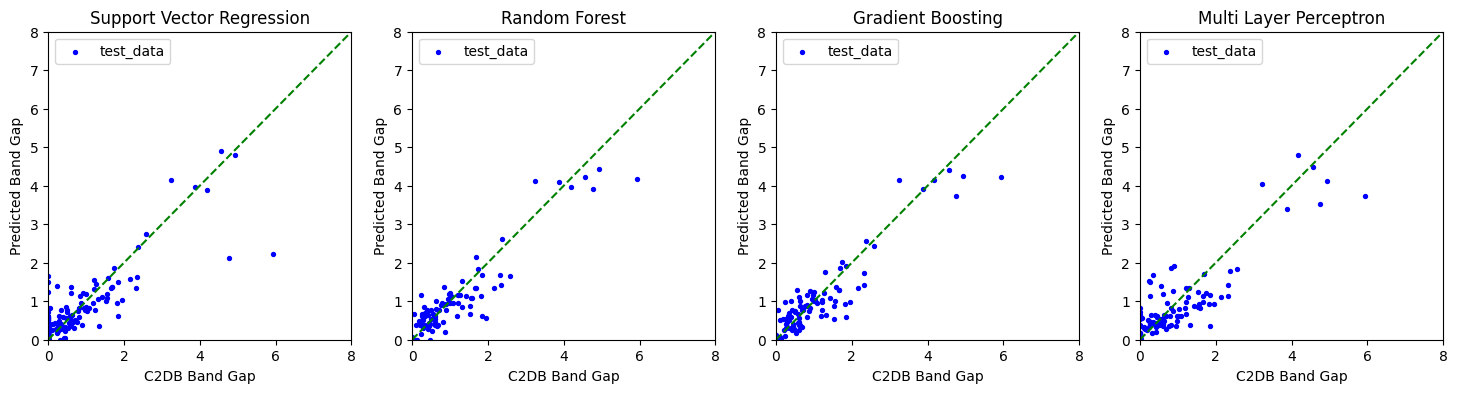

In [167]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
model_names = ['Support Vector Regression', 'Random Forest', 'Gradient Boosting', 'Multi Layer Perceptron']
predictions = [svr_pred, rf_pred, gbr_pred, mlp_pred]
for i in range(4):
    ax = axes[i]
    name = model_names[i]
    prediction = predictions[i]
    ax.scatter(y_test, prediction,s = 8, color = 'blue')
    ax.plot([0, 8], [0, 8], linestyle='--',color = 'green')
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 8)

    ax.set_xlabel('C2DB Band Gap')
    ax.set_ylabel('Predicted Band Gap')
    ax.set_title(name)
    ax.legend(['test_data'])

plt.show()

NEXT NOTEBOOK LINK - https://colab.research.google.com/drive/1RrNPpCq_TGQaY0JVZNi0h2YZvGmVXTbQ?usp=sharing